# Creative Writing — 3. MOJO Routing Analysis

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 20

POSITIVE_CATEGORIES = [
    "Adherence to Instructions", "Believable Character Actions", "Nuanced Characters",
    "Consistent Voice / Tone of Writing", "Imagery and Descriptive Quality", "Elegant Prose",
    "Emotionally Engaging", "Emotionally Complex", "Coherent",
    "Well-earned Lightness or Darkness", "Sentences Flow Naturally",
    "Overall Reader Engagement", "Overall Impression",
]
NEGATIVE_CATEGORIES = [
    "Meandering", "Weak Dialogue", "Tell-Don't-Show", "Unsurprising or Uncreative",
    "Amateurish", "Purple Prose", "Overwrought",
    "Incongruent Ending Positivity", "Unearned Transformations",
]
ALL_CATEGORIES = POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES
POS_COLS = [f"{c}_score" for c in POSITIVE_CATEGORIES]
NEG_COLS = [f"{c}_score" for c in NEGATIVE_CATEGORIES]
ALL_COLS = POS_COLS + NEG_COLS

def pretty_model(stem: str) -> str:
    return stem.replace("_result", "")

## Cost (for CLAUDE_BLENDED and cost_df)

In [2]:
def parse_log(path: Path) -> dict:
    tot_tok = lat = prompt = completion = n_ok = n_total = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            n_total += 1
            if e.get("status") == "ok":
                tot_tok    += e["total_tokens"]
                lat        += e["latency_ms"] / 1000
                prompt     += e["prompt_tokens"]
                completion += e["completion_tokens"]
                n_ok += 1
    return dict(n_ok=n_ok, n_total=n_total,
                total_tokens=tot_tok, latency_s=lat,
                prompt_tokens=prompt, completion_tokens=completion)

# Claude baseline
claude_raw = parse_log(LOGS_DIR / "llm_calls_claude-sonnet-4-6.jsonl")
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
CLAUDE_BLENDED = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Claude Sonnet 4.6  |  {claude_raw['n_ok']:,} requests  "
      f"|  blended ${CLAUDE_BLENDED:.2f}/1M tokens")

# Open-source models
cost_rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    tput      = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (tput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (tput * 3600)) * GPU_RATE_HIGH
    name = log_file.stem.replace("llm_calls_", "")
    cost_rows.append(dict(
        model=pretty_model(name),
        n_ok=raw["n_ok"],
        throughput=tput,
        cost_low=cost_low,
        cost_high=cost_high,
        cost_mid=(cost_low + cost_high) / 2,
        reduction_low=CLAUDE_BLENDED / cost_low,
        reduction_high=CLAUDE_BLENDED / cost_high,
    ))

cost_df = pd.DataFrame(cost_rows).sort_values("cost_low").reset_index(drop=True)

disp = cost_df[["model","n_ok","throughput","cost_low","cost_high","reduction_low","reduction_high"]].copy()
disp.columns = ["Model","N (ok)","Throughput (tok/s)","Cost/1M low","Cost/1M high","Reduction low","Reduction high"]
disp["Throughput (tok/s)"] = disp["Throughput (tok/s)"].map("{:.0f}".format)
disp["Cost/1M low"]  = disp["Cost/1M low"].map("${:.3f}".format)
disp["Cost/1M high"] = disp["Cost/1M high"].map("${:.3f}".format)
disp["Reduction low"]  = disp["Reduction low"].map("{:.1f}x".format)
disp["Reduction high"] = disp["Reduction high"].map("{:.1f}x".format)
display(disp)

Claude Sonnet 4.6  |  767 requests  |  blended $4.28/1M tokens


,Model,N (ok),Throughput (tok/s),Cost/1M low,Cost/1M high,Reduction low,Reduction high
0,Llama-3.2-3B-Instruct,811,2086,$0.266,$0.466,16.1x,9.2x
1,NVIDIA-Nemotron-3-Nano-4B-BF16,767,1706,$0.326,$0.570,13.1x,7.5x
2,gemma-4-E2B-it,767,1525,$0.364,$0.638,11.7x,6.7x
3,Qwen3.5-4B,767,1262,$0.440,$0.770,9.7x,5.6x
4,Qwen3-4B-Instruct-2507,767,1250,$0.444,$0.778,9.6x,5.5x
5,gemma-4-E4B-it,767,1012,$0.549,$0.960,7.8x,4.5x


## MOJO routing analysis

For each MAE threshold τ, MOJO routes each rubric to the cheapest open-source model whose bootstrap UCB-MAE ≤ τ, falling back to Claude otherwise.

In [3]:
def _load_pairs():
    """Load result CSVs and return (pairs, errors, evaluator_names) for bootstrap."""
    id_keys  = ["index", "model"]
    raw      = {p.stem: pd.read_csv(p) for p in sorted(RESULTS_DIR.glob("*_result.csv"))}
    baseline = pd.read_csv(RESULTS_DIR / BASELINE_FILE)
    raw.pop(Path(BASELINE_FILE).stem, None)

    evaluators      = {pretty_model(k): v for k, v in raw.items()}
    evaluator_names = sorted(evaluators.keys())

    pair_frames, err_frames = [], []
    for name, df in evaluators.items():
        m = df.merge(baseline, on=id_keys, suffixes=("_ev", "_ref"), validate="one_to_one")
        for cat in ALL_CATEGORIES:
            col = f"{cat}_score"
            ref = m[f"{col}_ref"].to_numpy()
            sc  = m[f"{col}_ev"].to_numpy()
            pair_frames.append(pd.DataFrame({
                "evaluator": name,
                "category":  cat,
                "type":      "positive" if cat in POSITIVE_CATEGORIES else "negative",
                "baseline":  ref,
                "score":     sc,
            }))
            block = m[id_keys].copy()
            block["category"] = cat
            block["evaluator"] = name
            block["abs_err"]   = np.abs(ref - sc)
            err_frames.append(block)

    return (pd.concat(pair_frames, ignore_index=True),
            pd.concat(err_frames, ignore_index=True),
            evaluator_names)


def bootstrap_calibration(pairs: pd.DataFrame, k: int, alpha: float,
                          seed: int) -> pd.DataFrame:
    """Bootstrap UCB calibration for routing: ucb_mae per (evaluator, category)."""
    rng  = np.random.default_rng(seed)
    rows = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        warnings.filterwarnings("ignore", message="An input array is constant")
        for (ev, cat), g in pairs.groupby(["evaluator", "category"], sort=False):
            x = g["baseline"].to_numpy()
            y = g["score"].to_numpy()
            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]
            n = len(x)
            if n < 2:
                continue
            m   = max(2, int(np.floor(np.sqrt(n))))
            mae = np.empty(k)
            for j in range(k):
                idx    = rng.integers(0, n, size=m)
                mae[j] = np.mean(np.abs(x[idx] - y[idx]))
            rows.append({"evaluator": ev, "category": cat,
                         "ucb_mae": float(np.quantile(mae, 1 - alpha))})
    return pd.DataFrame(rows)


MODEL_COST = dict(zip(cost_df["model"], cost_df["cost_mid"]))

In [4]:
pairs, errors, evaluator_names = _load_pairs()

cal = bootstrap_calibration(pairs, k=5, alpha=0.05, seed=0)
score_table = (
    cal.pivot_table(index="category", columns="evaluator", values="ucb_mae")
       .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)
cat_mae = (
    errors.groupby(["evaluator", "category"])["abs_err"].mean()
          .unstack("evaluator")
          .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)

n_per_cat = len(errors.groupby(["index", "model", "category"])["abs_err"].min()) // len(ALL_CATEGORIES)
print(f"Rubrics: {len(ALL_CATEGORIES)} | n per rubric: {n_per_cat}")
print(f"Evaluators: {evaluator_names}")
print(f"\nCost lookup ($/1M): {MODEL_COST}")

Rubrics: 22 | n per rubric: 767
Evaluators: ['Llama-3.2-3B-Instruct', 'NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']

Cost lookup ($/1M): {'Llama-3.2-3B-Instruct': 0.36614069520924764, 'NVIDIA-Nemotron-3-Nano-4B-BF16': 0.4478654314085847, 'gemma-4-E2B-it': 0.5009650996261064, 'Qwen3.5-4B': 0.6051166078621536, 'Qwen3-4B-Instruct-2507': 0.6110285509832712, 'gemma-4-E4B-it': 0.7545551575208305}


## Preprocess Step 1 — Global MAE exclusion  |  Step 2 — Ordinal alignment (Spearman ρ)

In [5]:
# === Preprocess Step 1: Global MAE-based model exclusion ===
# Exclude any model whose overall MAE is >1.75× the best model's MAE
global_mae = errors.groupby("evaluator")["abs_err"].mean().sort_values()
STEP1_MULTIPLIER = 1.75
STEP1_MAE_THRESH = global_mae.min() * STEP1_MULTIPLIER

CANDIDATE_MODELS = sorted(global_mae[global_mae <= STEP1_MAE_THRESH].index.tolist())
EXCLUDED_MODELS  = sorted(global_mae[global_mae >  STEP1_MAE_THRESH].index.tolist())

print("=== Preprocess Step 1: Global MAE Exclusion ===")
print(f"  Best MAE: {global_mae.min():.3f}  Threshold (×{STEP1_MULTIPLIER}): {STEP1_MAE_THRESH:.3f}")
for m in global_mae.index:
    tag = "EXCLUDED" if m in EXCLUDED_MODELS else "pass   "
    print(f"  {tag}  {m}  MAE={global_mae[m]:.3f}")
print(f"\n  Candidates after Step 1: {CANDIDATE_MODELS}")

# === Preprocess Step 2: per-rubric Spearman ρ (ordinal alignment) ===
RHO_MIN = 0.3   # minimum ordinal alignment to be routing-eligible per rubric

rho_rows = []
for (ev, cat), g in pairs.groupby(["evaluator", "category"]):
    x = g["baseline"].to_numpy()
    y = g["score"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rho, _ = stats.spearmanr(x, y)
    else:
        rho = np.nan
    rho_rows.append({"evaluator": ev, "category": cat, "spearman_rho": float(rho) if not np.isnan(rho) else np.nan})

rho_df    = pd.DataFrame(rho_rows)
rho_table = (
    rho_df.pivot_table(index="category", columns="evaluator", values="spearman_rho")
          .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)

print(f"\n=== Preprocess Step 2: Ordinal Alignment (Spearman ρ, min={RHO_MIN}) ===")
for m in evaluator_names:
    col    = rho_table[m]
    n_pass = int((col >= RHO_MIN).sum())
    if m in EXCLUDED_MODELS:
        tag = "STEP1-EXCLUDED"
    else:
        tag = f"{n_pass}/{len(ALL_CATEGORIES)} rubrics eligible"
    print(f"  {m}: {tag}  (mean ρ={col.mean():.3f})")

=== Preprocess Step 1: Global MAE Exclusion ===
  Best MAE: 1.836  Threshold (×1.75): 3.213
  pass     Qwen3.5-4B  MAE=1.836
  pass     gemma-4-E2B-it  MAE=2.492
  pass     gemma-4-E4B-it  MAE=2.947
  pass     NVIDIA-Nemotron-3-Nano-4B-BF16  MAE=3.014
  pass     Qwen3-4B-Instruct-2507  MAE=3.066
  EXCLUDED  Llama-3.2-3B-Instruct  MAE=3.926

  Candidates after Step 1: ['NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']

=== Preprocess Step 2: Ordinal Alignment (Spearman ρ, min=0.3) ===
  Llama-3.2-3B-Instruct: STEP1-EXCLUDED  (mean ρ=0.060)
  NVIDIA-Nemotron-3-Nano-4B-BF16: 1/22 rubrics eligible  (mean ρ=0.037)
  Qwen3-4B-Instruct-2507: 10/22 rubrics eligible  (mean ρ=0.298)
  Qwen3.5-4B: 20/22 rubrics eligible  (mean ρ=0.430)
  gemma-4-E2B-it: 4/22 rubrics eligible  (mean ρ=0.170)
  gemma-4-E4B-it: 15/22 rubrics eligible  (mean ρ=0.342)


In [6]:
THRESHOLDS = [("Max routing (τ=∞)", float("inf")),
              ("τ=2.6 (13%)",  2.6),
              ("τ=2.2 (11%)",  2.2),
              ("τ=1.8 (9%)",   1.8),
              ("τ=1.3 (6.5%)", 1.3)]

# Restrict score/rho tables to Step-1-approved candidates
score_cand = score_table[CANDIDATE_MODELS] if CANDIDATE_MODELS else score_table.iloc[:, :0]
rho_cand   = rho_table[CANDIDATE_MODELS]   if CANDIDATE_MODELS else rho_table.iloc[:, :0]

mojo_rows    = []
routing_maps = {}

for label, tau in THRESHOLDS:
    rubric_costs, rubric_maes, rubric_rhos, n_escalated = [], [], [], 0
    routing_map = {}
    for rubric in ALL_CATEGORIES:
        # Step 1 + Step 2 filter: eligible models with ucb_mae ≤ τ AND ρ ≥ RHO_MIN
        eligible = []
        for model in CANDIDATE_MODELS:
            ucb = score_cand.loc[rubric, model]
            rho = rho_cand.loc[rubric, model]
            if ucb <= tau and (not pd.isna(rho)) and rho >= RHO_MIN:
                eligible.append((ucb, model))   # sort by best MAE (paper: "best evaluator")

        if not eligible:
            rubric_costs.append(CLAUDE_BLENDED)
            rubric_maes.append(0.0)
            rubric_rhos.append(1.0)
            n_escalated += 1
            routing_map[rubric] = "Claude"
        else:
            eligible.sort()   # ascending UCB-MAE → best quality first
            _, model = eligible[0]
            rubric_costs.append(MODEL_COST.get(model, CLAUDE_BLENDED))
            rubric_maes.append(float(cat_mae.loc[rubric, model]))
            rubric_rhos.append(float(rho_cand.loc[rubric, model]))
            routing_map[rubric] = model

    routing_maps[label] = routing_map
    blended_cost = float(np.mean(rubric_costs))
    realized_mae = float(np.mean(rubric_maes))
    realized_rho = float(np.mean(rubric_rhos))
    mojo_rows.append(dict(
        label=label,
        n_escalated=n_escalated,
        blended_cost=blended_cost,
        realized_mae=realized_mae,
        realized_rho=realized_rho,
        reduction=CLAUDE_BLENDED / blended_cost,
    ))

mojo_df = pd.DataFrame(mojo_rows)
mojo_df["Cost/1M"]      = mojo_df["blended_cost"].map("${:.3f}".format)
mojo_df["Reduction"]    = mojo_df["reduction"].map("{:.1f}×".format)
mojo_df["Realized MAE"] = mojo_df["realized_mae"].map("{:.3f}".format)
mojo_df["Realized ρ"]   = mojo_df["realized_rho"].map("{:.3f}".format)
display(mojo_df[["label","n_escalated","Cost/1M","Reduction","Realized MAE","Realized ρ"]]
          .rename(columns={"label":"Threshold","n_escalated":"Rubrics → Claude"}))

no_fb    = mojo_df.iloc[0]
tightest_rows = mojo_df[mojo_df["n_escalated"] < len(ALL_CATEGORIES)]
tightest = tightest_rows.iloc[-1] if not tightest_rows.empty else no_fb
print(f"\nFor cost table (Creative Writing):")
print(f"  MOJO range: ${tightest['blended_cost']:.2f}–${no_fb['blended_cost']:.2f}/1M  "
      f"({no_fb['reduction']:.1f}–{tightest['reduction']:.1f}×)")

routing_df = pd.DataFrame(routing_maps, index=ALL_CATEGORIES)
routing_df.index.name = "Category"
print("\n=== Routing assignments per threshold ===")
display(routing_df)

,Threshold,Rubrics → Claude,Cost/1M,Reduction,Realized MAE,Realized ρ
0,Max routing (τ=∞),2,$0.934,4.6×,1.576,0.506
1,τ=2.6 (13%),5,$1.435,3.0×,1.297,0.584
2,τ=2.2 (11%),10,$2.270,1.9×,0.854,0.719
3,τ=1.8 (9%),15,$3.104,1.4×,0.443,0.845
4,τ=1.3 (6.5%),21,$4.106,1.0×,0.055,0.981



For cost table (Creative Writing):
  MOJO range: $4.11–$0.93/1M  (4.6–1.0×)

=== Routing assignments per threshold ===


,Max routing (τ=∞),τ=2.6 (13%),τ=2.2 (11%),τ=1.8 (9%),τ=1.3 (6.5%)
Category,,,,,
Adherence to Instructions,Claude,Claude,Claude,Claude,Claude
Believable Character Actions,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Nuanced Characters,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude,Claude
Consistent Voice / Tone of Writing,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Imagery and Descriptive Quality,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it
Elegant Prose,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Emotionally Engaging,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Emotionally Complex,Qwen3.5-4B,Qwen3.5-4B,Claude,Claude,Claude
Coherent,Qwen3.5-4B,Qwen3.5-4B,Claude,Claude,Claude


## Calibration cost

In [7]:
# Calibration cost: one-time GPU cost of running all open-source models on the calibration dataset
cal_cost_low, cal_cost_high, cal_total_tokens = 0.0, 0.0, 0

for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    gpu_hours = raw["latency_s"] / 3600
    cal_cost_low  += gpu_hours * GPU_RATE_LOW
    cal_cost_high += gpu_hours * GPU_RATE_HIGH
    cal_total_tokens += raw["total_tokens"]

cal_cost_mid = (cal_cost_low + cal_cost_high) / 2
n_cal_pairs  = len(ALL_CATEGORIES) * n_per_cat

mojo_no_fb_savings = CLAUDE_BLENDED - mojo_df.iloc[0]["blended_cost"]

print(f"=== Calibration Cost (Creative Writing) ===")
print(f"  One-time GPU cost: ${cal_cost_low:.2f}–${cal_cost_high:.2f}  (mid: ${cal_cost_mid:.2f})")
print(f"  Calibration set:   {n_per_cat} stories × {len(ALL_CATEGORIES)} rubrics = {n_cal_pairs:,} pairs")
print(f"  MOJO inference savings: ${mojo_no_fb_savings:.2f}/1M tokens vs pure Claude")
print(f"  → One-time calibration cost is ~{cal_cost_mid / (mojo_no_fb_savings * n_per_cat * cal_total_tokens / n_cal_pairs / 1_000_000):.0f}× the per-experiment inference saving")

=== Calibration Cost (Creative Writing) ===
  One-time GPU cost: $5.19–$9.08  (mid: $7.14)
  Calibration set:   767 stories × 22 rubrics = 16,874 pairs
  MOJO inference savings: $3.34/1M tokens vs pure Claude
  → One-time calibration cost is ~4× the per-experiment inference saving


## Pareto figure — cost vs MAE

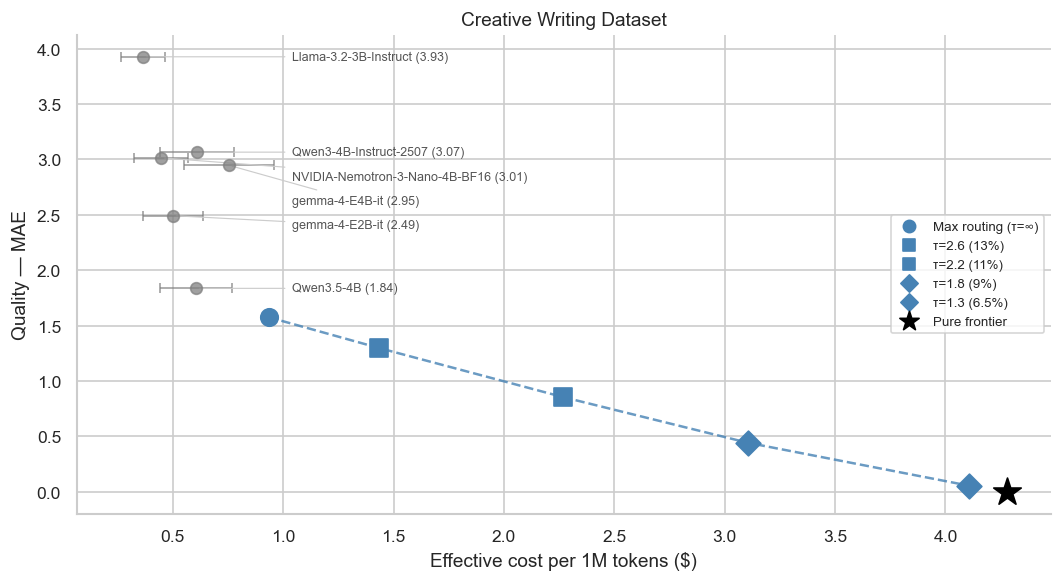

Saved pareto_creative_writing_mae.pdf


In [8]:
# Pareto figure — actual cost ($/1M) on x-axis
FIGURES_DIR = Path("../../neurips_paper2/figures")

# Compute overall MAE per model from errors
model_mae = (
    errors.groupby("evaluator")["abs_err"].mean()
    .reset_index()
    .rename(columns={"evaluator": "model", "abs_err": "Overall MAE"})
)
model_info = cost_df[["model", "cost_mid", "cost_low", "cost_high"]].copy()
model_info = model_info.merge(model_mae, on="model", how="inner")
model_info = model_info.sort_values("Overall MAE", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

# --- Grey model dots with staggered labels ---
for _, row in model_info.iterrows():
    xerr = (row["cost_high"] - row["cost_low"]) / 2
    ax.errorbar(row["cost_mid"], row["Overall MAE"], xerr=xerr,
                fmt="o", color="grey", alpha=0.75, markersize=7,
                elinewidth=1, capsize=3, zorder=3)

x_label = model_info["cost_high"].max() + 0.08
label_ys = list(model_info["Overall MAE"])
min_gap = 0.22
for i in range(1, len(label_ys)):
    if label_ys[i - 1] - label_ys[i] < min_gap:
        label_ys[i] = label_ys[i - 1] - min_gap

for (_, row), ly in zip(model_info.iterrows(), label_ys):
    ax.annotate(
        f"{row['model']} ({row['Overall MAE']:.2f})",
        xy=(row["cost_mid"], row["Overall MAE"]),
        xytext=(x_label, ly),
        fontsize=7.5, color="#555", ha="left", va="center",
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.7),
    )

# --- MOJO operating points ---
marker_map = ["o", "s", "s", "D", "D"]
mojo_sorted = mojo_df.sort_values("blended_cost").reset_index(drop=True)
ax.plot(mojo_sorted["blended_cost"], mojo_sorted["realized_mae"],
        "--", color="steelblue", lw=1.5, alpha=0.8, zorder=2)

for i, row in mojo_sorted.iterrows():
    ax.scatter(row["blended_cost"], row["realized_mae"],
               s=110, marker=marker_map[i], color="steelblue", zorder=4,
               label=row["label"])

# --- Pure frontier ---
ax.scatter(CLAUDE_BLENDED, 0, marker="*", s=300, color="black", zorder=5,
           label="Pure frontier")

ax.set_xlabel("Effective cost per 1M tokens ($)")
ax.set_ylabel("Quality — MAE")
ax.set_title("Creative Writing Dataset")
ax.legend(loc="center right", fontsize=8, frameon=True, markerscale=0.7)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_creative_writing_mae.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "pareto_creative_writing_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_creative_writing_mae.pdf")

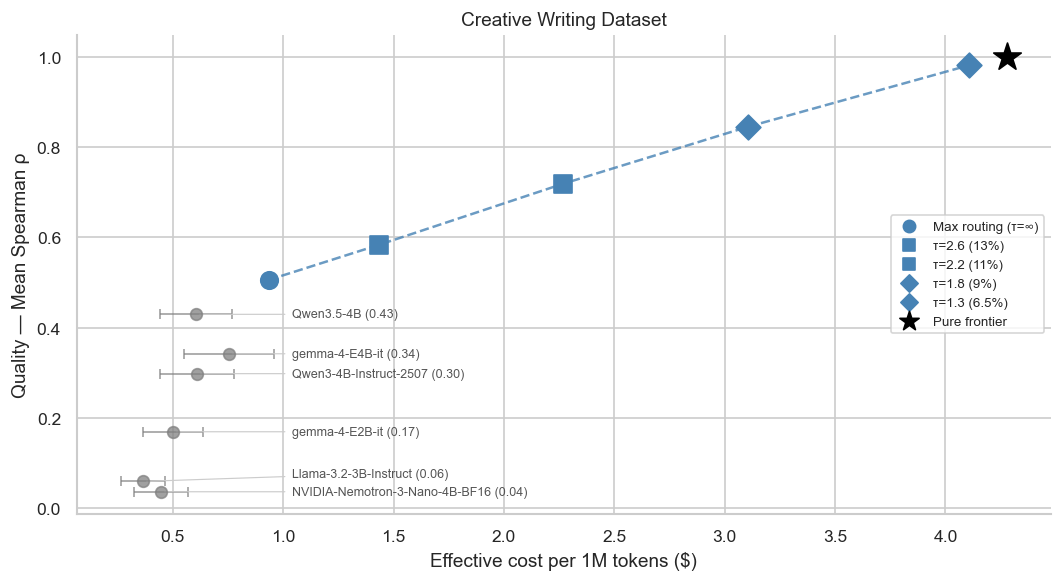

Saved pareto_creative_writing_rho.pdf


In [9]:
# Pareto figure — Spearman ρ on y-axis
model_rho = (
    rho_table.mean(axis=0)
    .reset_index()
    .rename(columns={"evaluator": "model", 0: "Mean Spearman rho"})
)
model_rho.columns = ["model", "Mean Spearman rho"]
model_info_rho = cost_df[["model", "cost_mid", "cost_low", "cost_high"]].copy()
model_info_rho = model_info_rho.merge(model_rho, on="model", how="inner")
model_info_rho = model_info_rho.sort_values("Mean Spearman rho").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

# --- Grey model dots ---
for _, row in model_info_rho.iterrows():
    xerr = (row["cost_high"] - row["cost_low"]) / 2
    ax.errorbar(row["cost_mid"], row["Mean Spearman rho"], xerr=xerr,
                fmt="o", color="grey", alpha=0.75, markersize=7,
                elinewidth=1, capsize=3, zorder=3)

x_label = model_info_rho["cost_high"].max() + 0.08
label_ys = list(model_info_rho["Mean Spearman rho"])
min_gap = 0.04
for i in range(1, len(label_ys)):
    if label_ys[i] - label_ys[i - 1] < min_gap:
        label_ys[i] = label_ys[i - 1] + min_gap

for (_, row), ly in zip(model_info_rho.iterrows(), label_ys):
    ax.annotate(
        f"{row['model']} ({row['Mean Spearman rho']:.2f})",
        xy=(row["cost_mid"], row["Mean Spearman rho"]),
        xytext=(x_label, ly),
        fontsize=7.5, color="#555", ha="left", va="center",
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.7),
    )

# --- MOJO operating points ---
marker_map = ["o", "s", "s", "D", "D"]
mojo_sorted = mojo_df.sort_values("blended_cost").reset_index(drop=True)
ax.plot(mojo_sorted["blended_cost"], mojo_sorted["realized_rho"],
        "--", color="steelblue", lw=1.5, alpha=0.8, zorder=2)

for i, row in mojo_sorted.iterrows():
    ax.scatter(row["blended_cost"], row["realized_rho"],
               s=110, marker=marker_map[i], color="steelblue", zorder=4,
               label=row["label"])

# --- Pure frontier ---
ax.scatter(CLAUDE_BLENDED, 1.0, marker="*", s=300, color="black", zorder=5,
           label="Pure frontier")

ax.set_xlabel("Effective cost per 1M tokens ($)")
ax.set_ylabel("Quality — Mean Spearman ρ")
ax.set_title("Creative Writing Dataset")
ax.legend(loc="center right", fontsize=8, frameon=True, markerscale=0.7)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_creative_writing_rho.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "pareto_creative_writing_rho.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_creative_writing_rho.pdf")